In [2]:
%pip install kagglehub pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yeanzc/telco-customer-churn-ibm-dataset")

print("Path to dataset files:", path)


files = os.listdir(path)
print(files)

c:\Users\kishk\Desktop\projects\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\kishk\.cache\kagglehub\datasets\yeanzc\telco-customer-churn-ibm-dataset\versions\1
['Telco_customer_churn.xlsx']


In [4]:
%pip install openpyxl
import pandas as pd
file_path = os.path.join(path, 'Telco_customer_churn.xlsx')

df = pd.read_excel(file_path)
df.iloc[:, 9:].head()

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [5]:
df.drop(columns=['Country', 'State', 'CustomerID', 'Lat Long',
        'Longitude', 'Latitude', 'Zip Code'], axis=1, inplace=True)

In [6]:
df['Total Charges'] = df['Total Charges'].astype(str)

In [7]:
df['Total Charges'] = df['Total Charges'].replace(' ', pd.NA)
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'] = df['Total Charges'].fillna(df['Total Charges'].mean())

In [8]:
df['Total Charges'] = df['Total Charges'].astype(int)

In [9]:
df.dtypes

Count                  int64
City                  object
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges          int64
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

In [10]:
df.head()

,Count,City,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,1,Los Angeles,Male,No,No,No,2,Yes,No,DSL,...,Month-to-month,Yes,Mailed check,53.85,108,Yes,1,86,3239,Competitor made better offer
1,1,Los Angeles,Female,No,No,Yes,2,Yes,No,Fiber optic,...,Month-to-month,Yes,Electronic check,70.70,151,Yes,1,67,2701,Moved
2,1,Los Angeles,Female,No,No,Yes,8,Yes,Yes,Fiber optic,...,Month-to-month,Yes,Electronic check,99.65,820,Yes,1,86,5372,Moved
3,1,Los Angeles,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,...,Month-to-month,Yes,Electronic check,104.80,3046,Yes,1,84,5003,Moved
4,1,Los Angeles,Male,No,No,Yes,49,Yes,Yes,Fiber optic,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036,Yes,1,89,5340,Competitor had better devices


In [11]:
df['City'].unique()

array(['Los Angeles', 'Beverly Hills', 'Huntington Park', ..., 'Standish',
       'Tulelake', 'Olympic Valley'], shape=(1129,), dtype=object)

In [12]:
import numpy as np
cols = ['Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
        'Multiple Lines', 'Online Security', 'Paperless Billing', 'Churn Label', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies']

for col in cols:
    df[col] = np.where(df[col].str.lower() == 'yes', 1, 0)

df['Gender'] = df['Gender'].map({'Male': 1, "Female": 0})

In [13]:
df.drop('Churn Label', axis=1, inplace=True)

df.drop('City', axis=1, inplace=True)
df.drop('Churn Reason', axis=1, inplace=True)

In [14]:
df.drop(["CLTV"], axis=1, inplace=True)

In [15]:
df.iloc[:, 9:].head()

,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,Churn Score
0,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108,1,86
1,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151,1,67
2,0,0,1,0,1,1,Month-to-month,1,Electronic check,99.65,820,1,86
3,0,0,1,1,1,1,Month-to-month,1,Electronic check,104.80,3046,1,84
4,0,1,1,0,1,1,Month-to-month,1,Bank transfer (automatic),103.70,5036,1,89


In [16]:
df.columns.str.strip()

Index(['Count', 'Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value',
       'Churn Score'],
      dtype='object')

In [17]:
df.rename(columns={"Churn Value": "Churn"}, inplace=True)

In [18]:
df.groupby("Contract")["Churn"].mean()

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64

In [19]:
df['Churn']

0       1
1       1
2       1
3       1
4       1
       ..
7038    0
7039    0
7040    0
7041    0
7042    0
Name: Churn, Length: 7043, dtype: int64

In [20]:
df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True)

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

In [21]:
df.groupby("Churn")["Tenure Months"].mean()

Churn
0    37.569965
1    17.979133
Name: Tenure Months, dtype: float64

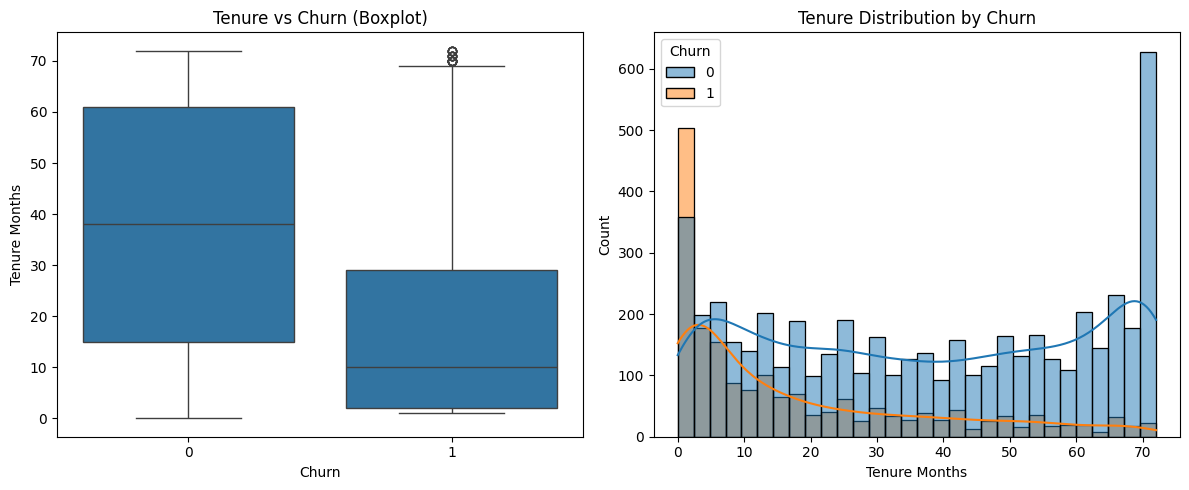

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns


fig, axes = plt.subplots(1, 2, figsize=(12, 5))


sns.boxplot(x='Churn', y='Tenure Months', data=df, ax=axes[0])
axes[0].set_title('Tenure vs Churn (Boxplot)')


sns.histplot(data=df, x='Tenure Months', hue='Churn',
             bins=30, kde=True, ax=axes[1])
axes[1].set_title('Tenure Distribution by Churn')

plt.tight_layout()
plt.show()

In [23]:
df.groupby("Churn")["Monthly Charges"].mean()

Churn
0    61.265124
1    74.441332
Name: Monthly Charges, dtype: float64

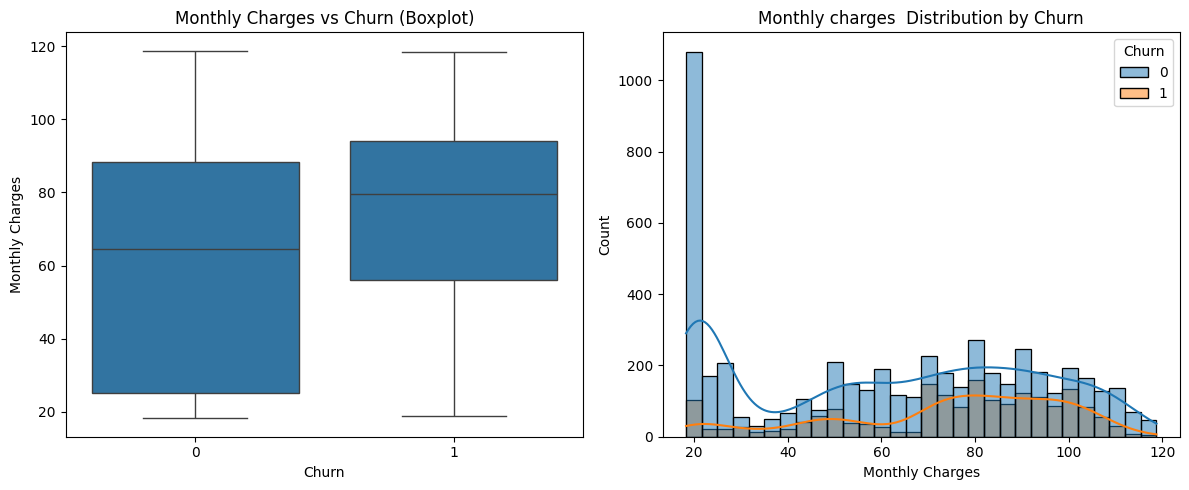

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x='Churn', y='Monthly Charges', data=df, ax=axes[0])
axes[0].set_title('Monthly Charges vs Churn (Boxplot)')


sns.histplot(data=df, x='Monthly Charges', hue='Churn',
             bins=30, kde=True, ax=axes[1])
axes[1].set_title('Monthly charges  Distribution by Churn')

plt.tight_layout()

plt.show()

In [25]:
df.groupby("Churn")["Total Charges"].mean()
# pople who dont leave , pays more

Churn
0    2554.297256
1    1531.323167
Name: Total Charges, dtype: float64

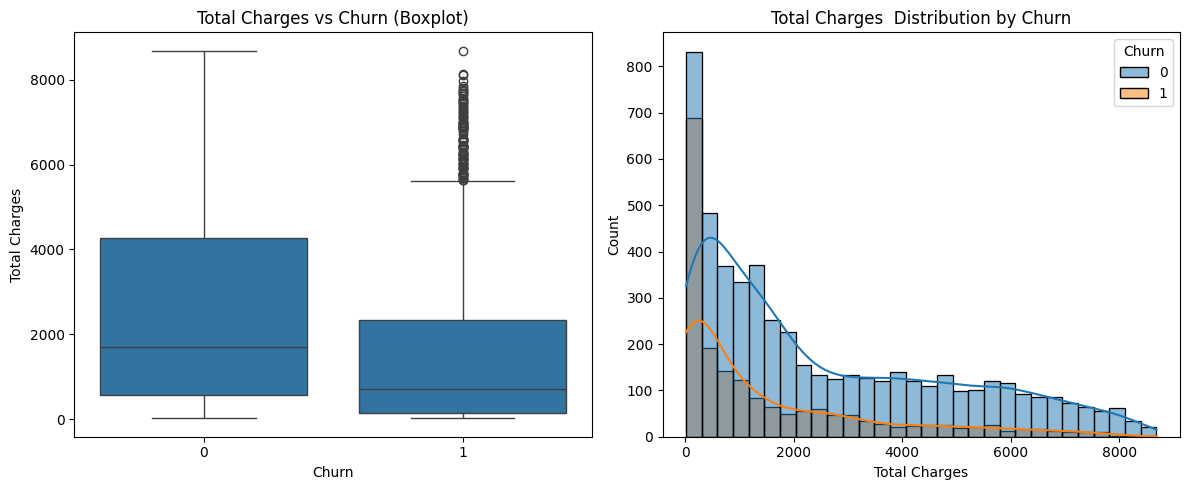

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x='Churn', y='Total Charges', data=df, ax=axes[0])
axes[0].set_title('Total Charges vs Churn (Boxplot)')


sns.histplot(data=df, x='Total Charges', hue='Churn',
             bins=30, kde=True, ax=axes[1])
axes[1].set_title('Total Charges  Distribution by Churn')

plt.tight_layout()

plt.show()

In [27]:
df.columns

Index(['Count', 'Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn',
       'Churn Score'],
      dtype='object')

In [28]:
cols = ['Contract', 'Internet Service', 'Tech Support',
        'Online Security', 'Streaming Movies']

for col in cols:
    print(f"\n--- {col} ---")
    print(df.groupby(col)['Churn'].mean().sort_values(ascending=False))


--- Contract ---
Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64

--- Internet Service ---
Internet Service
Fiber optic    0.418928
DSL            0.189591
No             0.074050
Name: Churn, dtype: float64

--- Tech Support ---
Tech Support
0    0.311862
1    0.151663
Name: Churn, dtype: float64

--- Online Security ---
Online Security
0    0.313296
1    0.146112
Name: Churn, dtype: float64

--- Streaming Movies ---
Streaming Movies
1    0.299414
0    0.243795
Name: Churn, dtype: float64


In [29]:
df.groupby(["Internet Service", "Churn"]).size()

Internet Service  Churn
DSL               0        1962
                  1         459
Fiber optic       0        1799
                  1        1297
No                0        1413
                  1         113
dtype: int64

In [30]:
X = df.drop(columns=['Churn', 'Churn Score', 'Count'], axis=1)
y = df['Churn']

In [31]:
X

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges
0,1,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108
1,0,0,0,1,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151
2,0,0,0,1,8,1,1,Fiber optic,0,0,1,0,1,1,Month-to-month,1,Electronic check,99.65,820
3,0,0,1,1,28,1,1,Fiber optic,0,0,1,1,1,1,Month-to-month,1,Electronic check,104.80,3046
4,1,0,0,1,49,1,1,Fiber optic,0,1,1,0,1,1,Month-to-month,1,Bank transfer (automatic),103.70,5036
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0,0,0,72,1,0,No,0,0,0,0,0,0,Two year,1,Bank transfer (automatic),21.15,1419
7039,1,0,1,1,24,1,1,DSL,1,0,1,1,1,1,One year,1,Mailed check,84.80,1990
7040,0,0,1,1,72,1,1,Fiber optic,0,1,1,0,1,1,One year,1,Credit card (automatic),103.20,7362
7041,0,0,1,1,11,0,0,DSL,1,0,0,0,0,0,Month-to-month,1,Electronic check,29.60,346


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

In [33]:
df.columns

Index(['Count', 'Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn',
       'Churn Score'],
      dtype='object')

In [34]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
num_cols = ["Tenure Months", "Monthly Charges", "Total Charges"]
cat_cols = ['Contract', 'Payment Method', 'Internet Service']


num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])
cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder(drop='first'))
])

In [35]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
], remainder='passthrough')

In [36]:
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

In [37]:
import joblib

joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']

In [38]:
X_processed = preprocessor.transform(X)

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_cluster = scaler.fit_transform(df[num_cols])

([<matplotlib.axis.XTick at 0x1fb7f0a5e50>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10')])

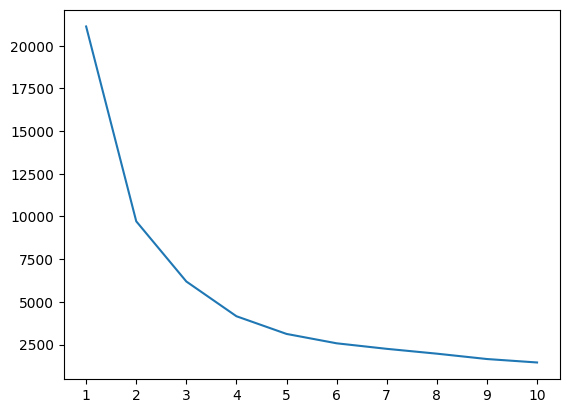

In [40]:
# doing clustering

from sklearn.cluster import KMeans

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(X_cluster)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.xticks(range(1, 11))

In [41]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df["Clusters"] = kmeans.fit_predict(X_cluster)

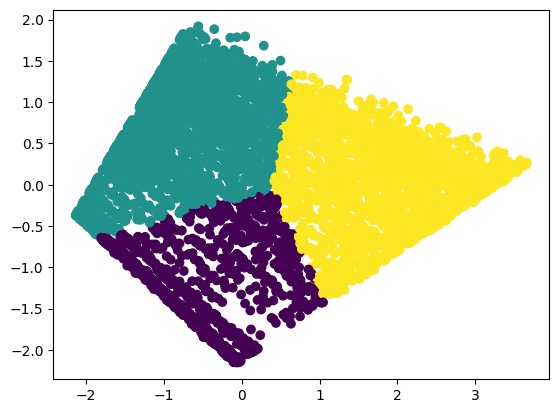

In [42]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

plt.scatter(df["PCA1"], df["PCA2"], c=df["Clusters"])

In [43]:
df[['Clusters']]

,Clusters
0,1
1,1
2,1
3,2
4,2
...,...
7038,0
7039,1
7040,2
7041,1


In [44]:
df.groupby("Clusters")[[
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "Churn"
]].mean()

,Tenure Months,Monthly Charges,Total Charges,Churn
Clusters,,,,
0,44.425272,29.591270,1341.250000,0.053668
1,10.748883,62.496783,756.132857,0.422997
2,57.141825,91.579291,5223.721319,0.167118


## observation:
cluster 0: high tenure 
                low monthly charges   -------- low churn-loyal customer

cluster1 :
                low tensure
                high monthlly charges ---------- high churn-high Risk customer

cluster 2:
                high tenure
                high monthly charge ----- High value customers

<Axes: xlabel='Clusters'>

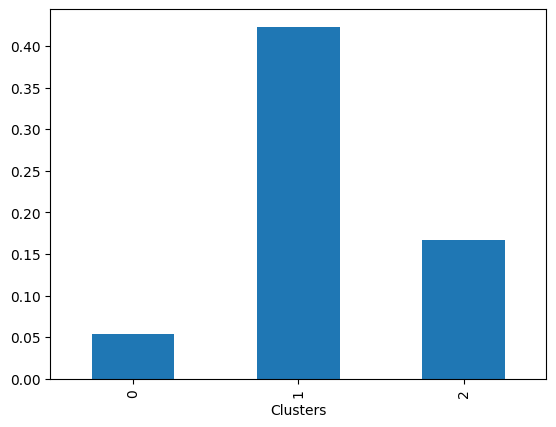

In [45]:
df.groupby("Clusters")["Churn"].mean().plot(kind="bar")

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

In [47]:
models = {
    "logistic regression": LogisticRegression(max_iter=10000),
    "KNN": KNeighborsClassifier(),
    "DT": DecisionTreeClassifier(random_state=42),
    "XGBOOST": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1)

}

In [48]:
models.items()

dict_items([('logistic regression', LogisticRegression(max_iter=10000)), ('KNN', KNeighborsClassifier()), ('DT', DecisionTreeClassifier(random_state=42)), ('XGBOOST', XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)), ('Random Forest', RandomForestClassifier(n_jobs=-1,

In [49]:
result = []

for name, model in models.items():
    model.fit(X_train_preprocessed, y_train)

    y_pred = model.predict(X_test_preprocessed)
    y_prob = model.predict_proba(X_test_preprocessed)[:, 1]

    result.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

c:\Users\kishk\Desktop\projects\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:50:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [50]:
result_df = pd.DataFrame(result)
result_df = result_df.sort_values(by="ROC-AUC", ascending=False)
result_df

,Model,Accuracy,Precision,Recall,ROC-AUC
0,logistic regression,0.808631,0.654028,0.591006,0.855599
4,Random Forest,0.797274,0.649457,0.511777,0.839669
3,XGBOOST,0.783078,0.605985,0.520343,0.835445
1,KNN,0.775128,0.573805,0.591006,0.795592
2,DT,0.744463,0.518438,0.511777,0.671004


In [51]:
best_model = models["XGBOOST"]
y_prob = best_model.predict_proba(X_test_preprocessed)[:, 1]

In [52]:
import joblib

joblib.dump(best_model, "churn_model.pkl")

['churn_model.pkl']

In [53]:
rf_params = {
    "n_estimators": [100, 200, 300, 500, 800],
    "max_depth": [None, 10, 20, 30, 40, 60],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}

xgb_params = {
    "n_estimators": [100, 200, 300, 500, 800],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "max_depth": [3, 4, 5, 6, 8, 10],
    "subsample": [0.5, 0.7, 0.8, 1.0],
    "colsample_bytree": [0.5, 0.7, 0.8, 1.0],
    "gamma": [0, 0.1, 0.2, 0.3, 0.5],
    "reg_alpha": [0, 0.01, 0.1, 1, 10],
    "reg_lambda": [1, 1.5, 2, 5, 10]
}

In [54]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
randomcv_models = [
    ("RF", RandomForestClassifier(), rf_params),
    ("XGboost", XGBClassifier(
        eval_metric="logloss",
        tree_method="hist",
        random_state=42
    ), xgb_params),
]

model_params = {}

for name, model, params in randomcv_models:
    random = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=30,
        cv=cv,
        verbose=2,
        n_jobs=-1,
        scoring="roc_auc",
        random_state=42,
        error_score="raise"
    )

    random.fit(X_train_preprocessed, y_train)

    model_params[name] = {
        "best_params": random.best_params_,
        "best_score": random.best_score_,
        "best_model": random.best_estimator_
    }

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [55]:
for name, details in model_params.items():
    print(f"\nModel: {name}")
    for k, v in details.items():
        print(f"  {k}: {v}")


Model: RF
  best_params: {'n_estimators': 500, 'min_samples_split': 20, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'max_depth': 20, 'bootstrap': True}
  best_score: 0.8581640168449519
  best_model: RandomForestClassifier(max_depth=20, min_samples_leaf=8, min_samples_split=20,
                       n_estimators=500)

Model: XGboost
  best_params: {'subsample': 0.8, 'reg_lambda': 1.5, 'reg_alpha': 10, 'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 0.5}
  best_score: 0.862451411564002
  best_model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.5, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.3,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, m

In [56]:
best_rf = model_params["RF"]["best_model"]
best_xgb = model_params["XGboost"]["best_model"]

In [57]:
# Fix:
joblib.dump(best_xgb, "churn_model.pkl")

['churn_model.pkl']

In [58]:
y_pred = best_xgb.predict(X_test_preprocessed)
y_prob = best_xgb.predict_proba(X_test_preprocessed)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.8625074052867956


In [59]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1175  119]
 [ 212  255]]


In [60]:
y_prob = best_xgb.predict_proba(X_test_preprocessed)[:, 1]

y_pred_custom = (y_prob > 0.4).astype(int)

=== Threshold: 0.5 (default) ===
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1294
           1       0.68      0.55      0.61       467

    accuracy                           0.81      1761
   macro avg       0.76      0.73      0.74      1761
weighted avg       0.80      0.81      0.80      1761

=== Threshold: 0.4 (custom) ===
              precision    recall  f1-score   support

           0       0.88      0.85      0.86      1294
           1       0.61      0.67      0.64       467

    accuracy                           0.80      1761
   macro avg       0.75      0.76      0.75      1761
weighted avg       0.81      0.80      0.80      1761



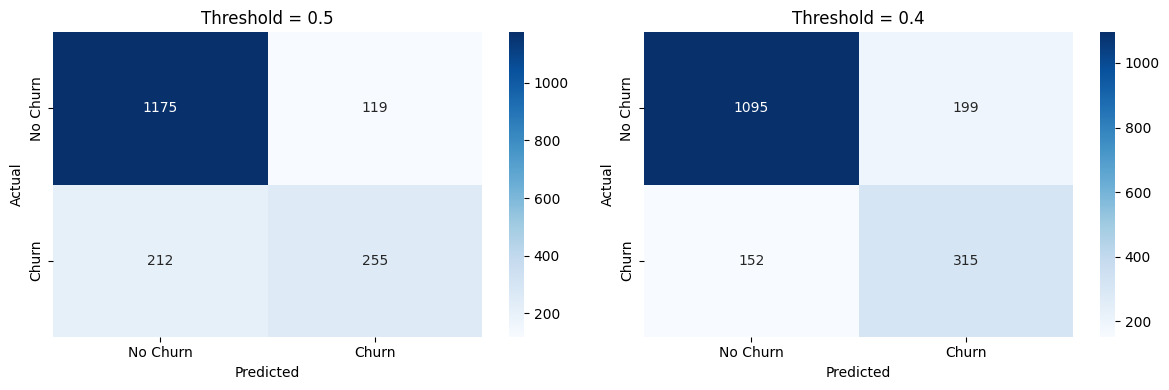

In [61]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve, f1_score
)


# ── 1. Compare default (0.5) vs custom (0.4) threshold ──────────────────────
y_pred_default = (y_prob > 0.5).astype(int)
y_pred_custom = (y_prob > 0.4).astype(int)

print("=== Threshold: 0.5 (default) ===")
print(classification_report(y_test, y_pred_default))

print("=== Threshold: 0.4 (custom) ===")
print(classification_report(y_test, y_pred_custom))


# ── 2. Confusion Matrix side by side ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title in zip(axes,
                            [y_pred_default, y_pred_custom],
                            ["Threshold = 0.5", "Threshold = 0.4"]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=["No Churn", "Churn"],
                yticklabels=["No Churn", "Churn"])
    ax.set_title(title)
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.tight_layout()
plt.show()


# ── 3. Precision-Recall curve — find the best F1 threshold ──────────────────
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

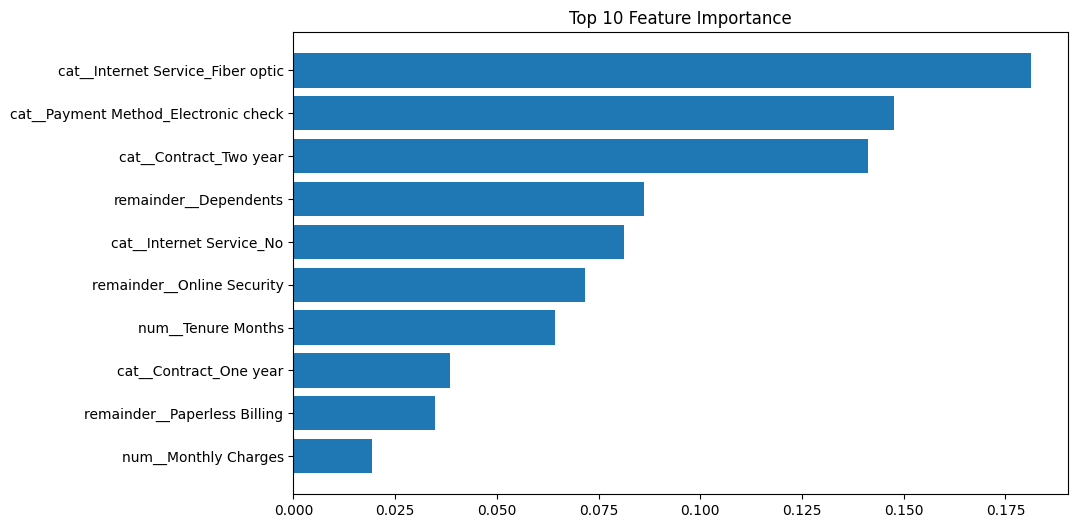

In [62]:
import matplotlib.pyplot as plt
import pandas as pd
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_xgb.feature_importances_
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)


plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"][:10], importance_df["Importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance")
plt.show()

In [ ]:

X_processed = preprocessor.transform(X)
df["Churn_Probability"] = best_xgb.predict_proba(X_processed)[:, 1]


def assign_risk(prob):
    if prob >= 0.70:
        return "Critical"
    elif prob >= 0.50:
        return "High"
    elif prob >= 0.30:
        return "Medium"
    else:
        return "Low"


df["Risk_Level"] = df["Churn_Probability"].apply(assign_risk)


segment_map = {
    0: " Loyal Advocates",
    1: " leaving Risk",
    2: " High Value"
}
df["Segment"] = df["Clusters"].map(segment_map)

df.to_csv("customer_data.csv", index=False)
result_df.to_csv("final_result_df.csv", index=False)
joblib.dump(best_xgb, "final_model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

print("✅ customer_data.csv   →", df.shape)
print("✅ final_result_df.csv →", result_df.shape)
print("✅ final_model.pkl     → saved")
print("✅ preprocessor.pkl    → saved")

✅ customer_data.csv   → (7043, 28)
✅ final_result_df.csv → (5, 5)
✅ final_model.pkl     → saved
✅ preprocessor.pkl    → saved
